In [1]:
# =============================================================================
# CELL 1 — CONFIGURATION & DATA FETCHING (REFACTORED FOR US STOCKS ONLY)
# 
# Workflow:
#   1. Scan S&P 500 for daily movers using Finnhub /quote
#   2. Fetch OHLC history from yfinance (with fallback for failed requests)
#   3. Analyze watchlist for performance tracking
#   4. Output: ohlc_data, watchlist_ohlc_data, top5_symbols (ready for charts)
# =============================================================================

import os
import time
import requests
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
from dotenv import load_dotenv
from pytickersymbols import PyTickerSymbols
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# ============================================================================
# CONFIGURATION SECTION
# ============================================================================
load_dotenv()

FINNHUB_API_KEY  = os.getenv("FINNHUB_API_KEY", "")
FINNHUB_BASE_URL = "https://finnhub.io/api/v1"
REQUEST_DELAY    = 2.0   # seconds between Finnhub requests (avoids rate limiting)
MAX_REQUESTS     = 60    # Finnhub free tier quota
OHLC_DAYS        = 7     # look-back window for historical OHLC data
SCAN_LIMIT       = 50    # how many S&P 500 tickers to scan for movers
TARGET_MOVERS    = 5     # target number of valid movers to fetch

# US Market Configuration (filters out non-US stocks)
US_EXCHANGES     = ["NYSE", "NASDAQ", "AMEX"]
US_CURRENCY      = "USD"
MIN_PRICE        = 0.01
MAX_PRICE        = 100000.0
OTC_SUFFIXES     = ["F", "Q", "Y", "K", "U", "V"]  # Delisted/OTC indicators

# Watchlist of favorite stocks to monitor
WATCHLIST = ["AAPL", "NVDA", "MSFT", "META", "GOOGL"]

# Company name mapping (for better readability)
SYMBOL_NAMES = {
    "AAPL":  "Apple Inc.",
    "MSFT":  "Microsoft Corporation",
    "NVDA":  "NVIDIA Corporation",
    "TSLA":  "Tesla Inc.",
    "AMZN":  "Amazon Inc.",
    "GOOGL": "Alphabet Inc.",
    "META":  "Meta Platforms",
    "BRK.B": "Berkshire Hathaway",
    "JNJ":   "Johnson & Johnson",
    "V":     "Visa Inc.",
}

if not FINNHUB_API_KEY:
    raise ValueError(
        "FINNHUB_API_KEY not set.\n"
        "1. Visit https://finnhub.io to get a free key.\n"
        "2. Add FINNHUB_API_KEY=<your_key> to a .env file.\n"
        "3. Restart the kernel and re-run."
    )

# ============================================================================
# SESSION & HELPER FUNCTIONS
# ============================================================================

_request_count = 0
_session = None

def _get_session():
    """Create requests session with exponential backoff retry logic."""
    global _session
    if _session is None:
        _session = requests.Session()
        retry = Retry(
            total=3,
            backoff_factor=0.5,
            status_forcelist=[429, 500, 502, 503, 504],
            allowed_methods=["GET"]
        )
        adapter = HTTPAdapter(max_retries=retry)
        _session.mount("http://", adapter)
        _session.mount("https://", adapter)
        _session.headers.update({
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
        })
    return _session


def get_company_name(symbol: str) -> str:
    """Return friendly company name or symbol if not in mapping."""
    return SYMBOL_NAMES.get(symbol, symbol)


def _is_us_stock(symbol: str) -> bool:
    """
    Validate if symbol is a US-listed stock (NYSE/NASDAQ only).
    Filters: OTC, delisted, foreign exchanges, crypto
    """
    # Exclude foreign exchange suffixes
    if any(symbol.endswith(suffix) for suffix in [".L", ".TO", ".V", ".AX", ".HK", ".KL", ".T", ".SI"]):
        return False
    
    # Exclude OTC and delisted stocks
    if any(symbol.endswith(suffix) for suffix in OTC_SUFFIXES):
        return False
    
    # Exclude forex and crypto
    if any(pat in symbol.upper() for pat in ["=X", "BTC", "ETH", "DOGE", "USDT"]):
        return False
    
    return True


def _validate_us_market_data(data: dict, symbol: str) -> bool:
    """Validate Finnhub response contains valid US market data."""
    try:
        current_price = data.get("c", 0)
        prev_close = data.get("pc", 0)
        
        # Check price range and data completeness
        if current_price <= MIN_PRICE or current_price > MAX_PRICE:
            return False
        if prev_close is None or prev_close == 0:
            return False
        
        return True
    except:
        return False


def _api_get(endpoint: str, params: dict | None = None) -> dict:
    """Call Finnhub API with rate limiting and retry logic."""
    global _request_count
    if _request_count >= MAX_REQUESTS:
        return {}
    
    _request_count += 1
    params = {**(params or {}), "token": FINNHUB_API_KEY}
    session = _get_session()
    
    try:
        r = session.get(
            f"{FINNHUB_BASE_URL}{endpoint}", 
            params=params, 
            timeout=15
        )
        r.raise_for_status()
        return r.json() or {}
    except:
        return {}
    finally:
        time.sleep(REQUEST_DELAY)


def fetch_quote(symbol: str) -> dict:
    """Fetch current day quote from Finnhub."""
    if not _is_us_stock(symbol):
        return {"symbol": symbol, "current": 0, "prev_close": 0}
    
    raw = _api_get("/quote", {"symbol": symbol})
    
    if raw and not _validate_us_market_data(raw, symbol):
        return {"symbol": symbol, "current": 0, "prev_close": 0}
    
    return {
        "symbol":     symbol,
        "current":    raw.get("c", 0),
        "prev_close": raw.get("pc", 0),
    }


def fetch_ohlc(symbol: str, days: int = OHLC_DAYS) -> pd.DataFrame:
    """Fetch OHLC history from yfinance with exponential backoff retry."""
    if not _is_us_stock(symbol):
        return pd.DataFrame()
    
    end   = datetime.now()
    start = end - timedelta(days=days + 4)
    
    max_retries = 3
    backoff_base = 0.5
    
    for attempt in range(max_retries):
        try:
            ticker = yf.Ticker(symbol)
            df = ticker.history(
                start=start.strftime("%Y-%m-%d"),
                end=end.strftime("%Y-%m-%d"),
                interval="1d",
                auto_adjust=True
            )
            
            if df.empty:
                return pd.DataFrame()
            
            df = df[["Open", "High", "Low", "Close"]].copy()
            df = df[(df["Close"] > MIN_PRICE) & (df["Close"] < MAX_PRICE)]
            
            if df.empty:
                return pd.DataFrame()
            
            df.index = pd.to_datetime(df.index).normalize().tz_localize(None)
            return df.tail(days)
            
        except:
            if attempt < max_retries - 1:
                time.sleep(backoff_base * (2 ** attempt))
                continue
    
    return pd.DataFrame()


def _pct_change(quote: dict) -> float | None:
    """Calculate daily % change or None if invalid."""
    c, pc = quote["current"], quote["prev_close"]
    return (c - pc) / pc * 100 if c > 0 and pc > 0 else None


# ============================================================================
# STEP 1 — SCAN S&P 500 FOR TOP DAILY MOVERS
# ============================================================================
print("=" * 75)
print(f" STEP 1 — Scanning S&P 500 for top {TARGET_MOVERS} daily movers")
print(f"          Source: Finnhub /quote (free tier, US stocks only)")
print("=" * 75)

sp500_tickers = list(PyTickerSymbols().get_sp_500_nyc_yahoo_tickers())[:SCAN_LIMIT]
print(f"  ✓ Loaded {len(sp500_tickers)} S&P 500 tickers\n")

mover_scores: list[tuple[str, float]] = []

for i, sym in enumerate(sp500_tickers, 1):
    if _request_count >= MAX_REQUESTS:
        print("  ⚠ Budget exhausted during scan.")
        break
    
    print(f"  [{i:02}/{len(sp500_tickers)}] {sym:<8}", end="", flush=True)
    
    if not _is_us_stock(sym):
        print(" — not US stock")
        continue
    
    q = fetch_quote(sym)
    pct = _pct_change(q)
    
    if pct is None:
        print(" — no data")
    else:
        mover_scores.append((sym, pct))
        print(f" {pct:+.2f}%")

print(f"\n  Found {len(mover_scores)} valid movers")
mover_scores.sort(key=lambda x: x[1], reverse=True)
print(f"  Top candidates: {[s for s, _ in mover_scores[:TARGET_MOVERS]]}")
print(f"  Requests used: {_request_count}/{MAX_REQUESTS}\n")

# ============================================================================
# STEP 2 — FETCH OHLC FOR TOP MOVERS (WITH FALLBACK)
# ============================================================================
print("=" * 75)
print(f" STEP 2 — Fetching {OHLC_DAYS}-day OHLC for top movers")
print(f"          Source: yfinance (free, no API key)")
print(f"          Fallback: Auto-fetch next mover if OHLC fails")
print("=" * 75)

ohlc_data: dict[str, pd.DataFrame] = {}
top5_symbols = []
scan_index = 0

while len(ohlc_data) < TARGET_MOVERS and scan_index < len(mover_scores):
    sym, pct = mover_scores[scan_index]
    scan_index += 1
    
    print(f"  {sym} ...", end="", flush=True)
    df = fetch_ohlc(sym)
    
    if df.empty:
        print(" ✗ no data (delisted)")
    else:
        ohlc_data[sym] = df
        top5_symbols.append(sym)
        print(f" ✓ ({len(df)} days)")

# Fallback: use defaults if not enough movers
if len(ohlc_data) < TARGET_MOVERS:
    print(f"\n  ⚠ Only {len(ohlc_data)} movers — adding defaults")
    for default_sym in ["AAPL", "MSFT", "NVDA", "TSLA", "AMZN"]:
        if len(ohlc_data) >= TARGET_MOVERS:
            break
        if default_sym not in top5_symbols:
            print(f"  {default_sym}...", end="", flush=True)
            df = fetch_ohlc(default_sym)
            if not df.empty:
                ohlc_data[default_sym] = df
                top5_symbols.append(default_sym)
                print(f" ✓")
            else:
                print(f" ✗")

print(f"\n  ✓ Top {len(ohlc_data)} movers: {top5_symbols}")
print(f"  Requests used: {_request_count}/{MAX_REQUESTS}\n")

# ============================================================================
# STEP 3 — FETCH WATCHLIST DATA
# ============================================================================
print("=" * 75)
print(f" STEP 3 — Fetching quotes & OHLC for watchlist")
print(f"          Stocks: {', '.join(WATCHLIST)}")
print("=" * 75)

watchlist_performance: list[tuple[str, float]] = []
watchlist_ohlc_data:   dict[str, pd.DataFrame] = {}

for sym in WATCHLIST:
    if not _is_us_stock(sym):
        print(f"  {sym} ✗ (not US stock)")
        continue
    
    print(f"  {sym} ...", end="", flush=True)
    
    q   = fetch_quote(sym)
    pct = _pct_change(q)
    if pct is not None:
        watchlist_performance.append((sym, pct))
    
    df = fetch_ohlc(sym)
    if not df.empty:
        watchlist_ohlc_data[sym] = df
    
    status = f"quote={pct:+.2f}%" if pct else "no quote"
    print(f" ✓ {status}")

watchlist_performance.sort(key=lambda x: x[1], reverse=True)

print(f"\n  Total requests used: {_request_count}/{MAX_REQUESTS}")

 STEP 1 — Scanning S&P 500 for top 5 daily movers
          Source: Finnhub /quote (free tier, US stocks only)
  ✓ Loaded 50 S&P 500 tickers

  [01/50] MMM      +1.19%
  [02/50] ABT      -1.17%
  [03/50] ACN      +0.94%
  [04/50] ADBE     -0.53%
  [05/50] ALB      +2.48%
  [06/50] ALGN     -0.01%
  [07/50] ALLE     +0.34%
  [08/50] GOOGL    +0.90%
  [09/50] GOOG     +0.89%
  [10/50] GOOGL    +0.90%
  [11/50] GOOG     +0.89%
  [12/50] AMZN     +2.41%
  [13/50] AMCR     +2.11%
  [14/50] AMCCF    — not US stock
  [15/50] AMGN     +1.11%
  [16/50] AON      +0.13%
  [17/50] APA      -0.96%
  [18/50] AAPL     +0.70%
  [19/50] APTV     — not US stock
  [20/50] AJG      -0.68%
  [21/50] T        +0.20%
  [22/50] BKR      -5.54%
  [23/50] BLL      — no data
  [24/50] BALY     — not US stock
  [25/50] BALL     +0.37%
  [26/50] BAC      -2.20%
  [27/50] BOAPL    — no data
  [28/50] BAX      +0.98%
  [29/50] BRK-B    -0.66%
  [30/50] BLK      — not US stock
  [31/50] BA       +1.90%
  [32/50] BSX 

## Summary

✅ **Data Generated from Cell 1:**
- `top5_symbols`: Top 5 daily movers
- `ohlc_data`: OHLC history for each mover
- `watchlist_ohlc_data`: OHLC history for watchlist stocks
- `watchlist_performance`: Daily % change for watchlist

✅ **Cell 2 Output:**
- Investment score for each stock (BUY/HOLD/AVOID)
- Simple trading recommendations
- Portfolio strategy guide

In [2]:
# =============================================================================
# CELL 2 — INVESTMENT ANALYSIS & SCORING
# Analyzes market data to calculate investment scores for each stock
# Based on: momentum (% change), trend strength, and volatility
# =============================================================================

import pandas as pd
import numpy as np

print("=" * 80)
print(" 📊 STOCK ANALYSIS & INVESTMENT SCORING")
print("=" * 80)

# ============================================================================
# SECTION 1 — TOP 5 MOVERS ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print(" SECTION 1 — TOP 5 MOVERS (Daily Momentum Leaders)")
print("=" * 80)

mover_analysis = []
for sym in top5_symbols:
    if sym in ohlc_data:
        df = ohlc_data[sym]
        close_prices = df["Close"].values
        
        # Calculate metrics
        daily_pct = _pct_change(fetch_quote(sym)) or 0
        seven_day_return = (close_prices[-1] / close_prices[0] - 1) * 100
        volatility = df["Close"].std() / df["Close"].mean() * 100
        high_low_range = (df["High"].max() - df["Low"].min()) / df["Close"].mean() * 100
        
        mover_analysis.append({
            "Symbol": sym,
            "Company": get_company_name(sym),
            "Today %": daily_pct,
            "7-Day %": seven_day_return,
            "Volatility %": volatility,
            "Price Range %": high_low_range,
            "Trend": "📈 UP" if seven_day_return > 0 else "📉 DOWN",
        })

mover_df = pd.DataFrame(mover_analysis)
print("\n" + mover_df.to_string(index=False))

# Scoring for top movers
print("\n" + "-" * 80)
print(" 🎯 TOP MOVERS INVESTMENT SCORE")
print("-" * 80)

mover_scores_list = []
for _, row in mover_df.iterrows():
    # Simple scoring: momentum (60%) + trend stability (40%)
    momentum_score = (row["Today %"] + row["7-Day %"]) / 2 * 0.6
    stability_score = (100 / (row["Volatility %"] + 1)) * 0.4  # Lower vol = higher score
    total_score = momentum_score + stability_score
    
    mover_scores_list.append({
        "Symbol": row["Symbol"],
        "Momentum": row["Today %"],
        "Score": total_score,
        "Recommendation": (
            "🟢 BUY" if total_score > 5 else 
            "🟡 HOLD" if total_score > 2 else 
            "🔴 AVOID"
        )
    })

score_df = pd.DataFrame(mover_scores_list).sort_values("Score", ascending=False)
for _, row in score_df.iterrows():
    print(f"  {row['Symbol']:<8} Score: {row['Score']:>6.2f}  {row['Recommendation']}")

# ============================================================================
# SECTION 2 — WATCHLIST ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print(" SECTION 2 — WATCHLIST (Established Holdings)")
print("=" * 80)

watchlist_analysis = []
for sym in WATCHLIST:
    if sym in watchlist_ohlc_data:
        df = watchlist_ohlc_data[sym]
        close_prices = df["Close"].values
        
        # Calculate metrics
        daily_pct = next(
            (p for s, p in watchlist_performance if s == sym),
            0
        )
        seven_day_return = (close_prices[-1] / close_prices[0] - 1) * 100
        volatility = df["Close"].std() / df["Close"].mean() * 100
        sma_7 = close_prices[-7:].mean() if len(close_prices) >= 7 else close_prices.mean()
        current_price = close_prices[-1]
        ma_ratio = (current_price / sma_7 - 1) * 100 if sma_7 > 0 else 0
        
        watchlist_analysis.append({
            "Symbol": sym,
            "Company": get_company_name(sym),
            "Today %": daily_pct,
            "7-Day %": seven_day_return,
            "Volatility %": volatility,
            "vs 7-MA %": ma_ratio,
            "Current $": current_price,
        })
    else:
        watchlist_analysis.append({
            "Symbol": sym,
            "Company": get_company_name(sym),
            "Today %": 0,
            "7-Day %": 0,
            "Volatility %": 0,
            "vs 7-MA %": 0,
            "Current $": 0,
        })

watchlist_df = pd.DataFrame(watchlist_analysis)
print("\n" + watchlist_df.to_string(index=False))

# Scoring for watchlist
print("\n" + "-" * 80)
print(" 🎯 WATCHLIST INVESTMENT SCORE")
print("-" * 80)

watchlist_scores_list = []
for _, row in watchlist_df.iterrows():
    if row["Current $"] > 0:
        # Score: Positive momentum (50%) + Above moving avg (50%)
        momentum_score = row["7-Day %"] * 0.5
        ma_score = row["vs 7-MA %"] * 0.5
        total_score = momentum_score + ma_score
        
        watchlist_scores_list.append({
            "Symbol": row["Symbol"],
            "Score": total_score,
            "Recommendation": (
                "🟢 BUY/HOLD" if total_score > 1 else 
                "🟡 HOLD" if total_score > -1 else 
                "🔴 CONSIDER SELLING"
            )
        })
    else:
        watchlist_scores_list.append({
            "Symbol": row["Symbol"],
            "Score": 0,
            "Recommendation": "⚠️  NO DATA"
        })

wl_score_df = pd.DataFrame(watchlist_scores_list).sort_values("Score", ascending=False)
for _, row in wl_score_df.iterrows():
    print(f"  {row['Symbol']:<8} Score: {row['Score']:>6.2f}  {row['Recommendation']}")


 📊 STOCK ANALYSIS & INVESTMENT SCORING

 SECTION 1 — TOP 5 MOVERS (Daily Momentum Leaders)

Symbol     Company  Today %   7-Day %  Volatility %  Price Range %  Trend
   CDW         CDW 5.608251  4.992184      2.690111       9.175005   📈 UP
   CCL         CCL 4.605017  7.226011      4.017724      14.209497   📈 UP
   CRH         CRH 3.741064 -1.238030      1.622350       6.445975 📉 DOWN
   ALB         ALB 2.478677 -0.597475      1.601739       9.665219 📉 DOWN
  AMZN Amazon Inc. 2.310679  0.162359      1.142200       5.511932   📈 UP

--------------------------------------------------------------------------------
 🎯 TOP MOVERS INVESTMENT SCORE
--------------------------------------------------------------------------------
  AMZN     Score:  19.41  🟢 BUY
  CRH      Score:  16.00  🟢 BUY
  ALB      Score:  15.94  🟢 BUY
  CDW      Score:  14.02  🟢 BUY
  CCL      Score:  11.52  🟢 BUY

 SECTION 2 — WATCHLIST (Established Holdings)

Symbol               Company   Today %   7-Day %  Volatility %

## Top 5 Movers - 7-Day OHLC Charts

Visualize the top 5 daily movers with:
- **Chart 1**: Seaborn line charts (Open, High, Low, Close)
- **Chart 2**: Matplotlib absolute vs relative price comparison

**Data Source**: `ohlc_data` from Cell 1
**Execution Order**: Run Cell 1 → Cell 2 → Cell 3

Rendering Chart 1 — Top 5 Movers OHLC …


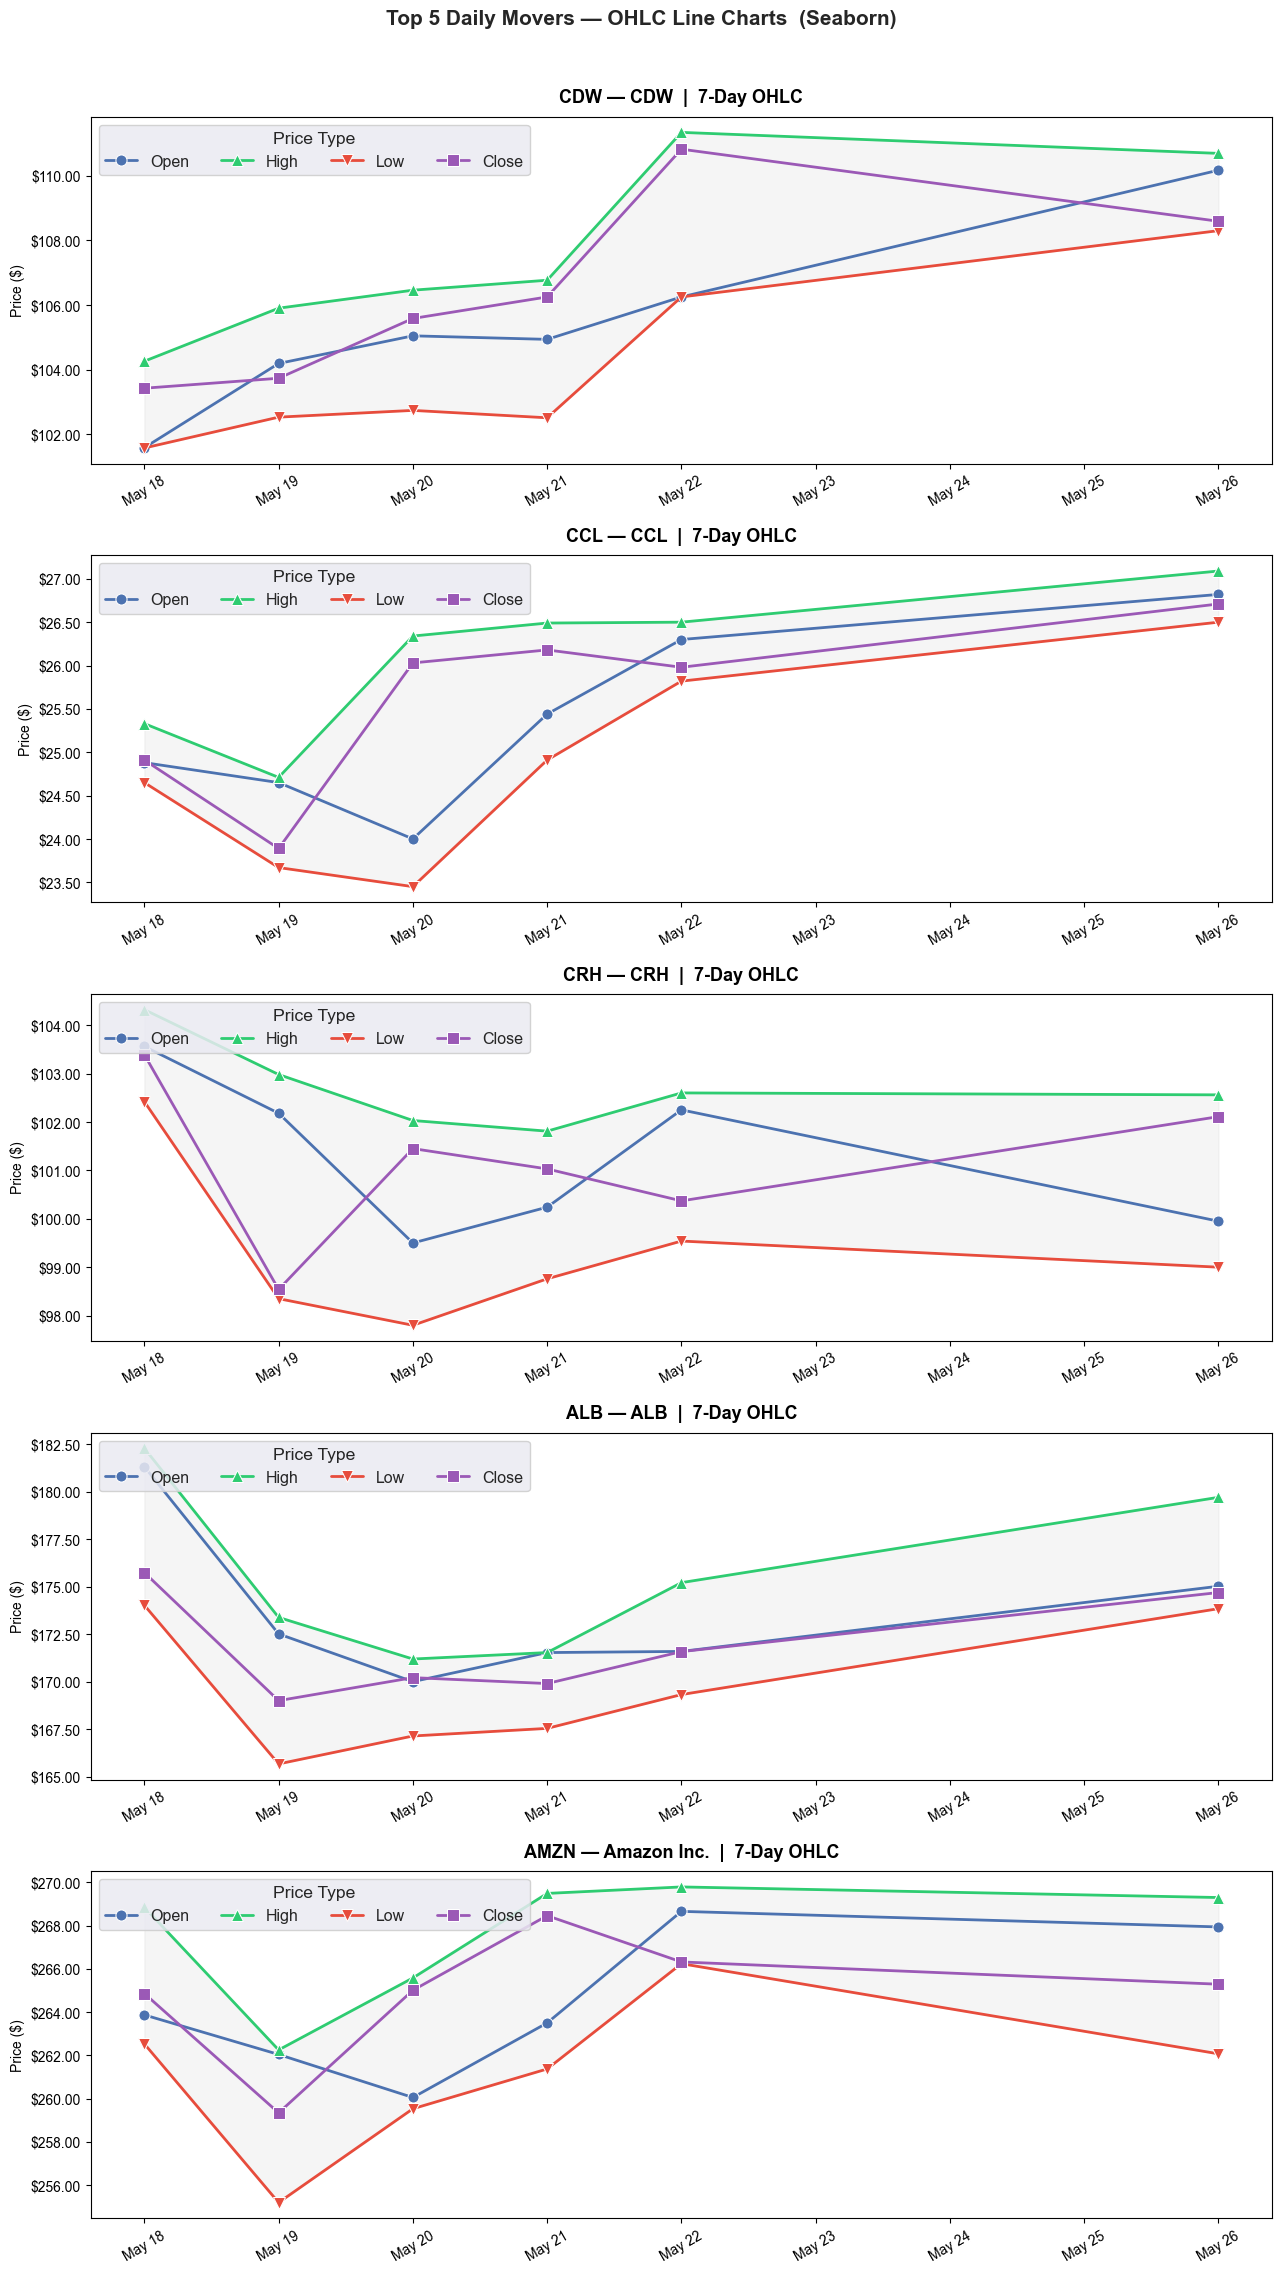

Rendering Chart 2 — Top 5 Movers Close Price Comparison …


C:\Users\jancq\AppData\Local\Temp\ipykernel_2520\2910061998.py:104: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jancq\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


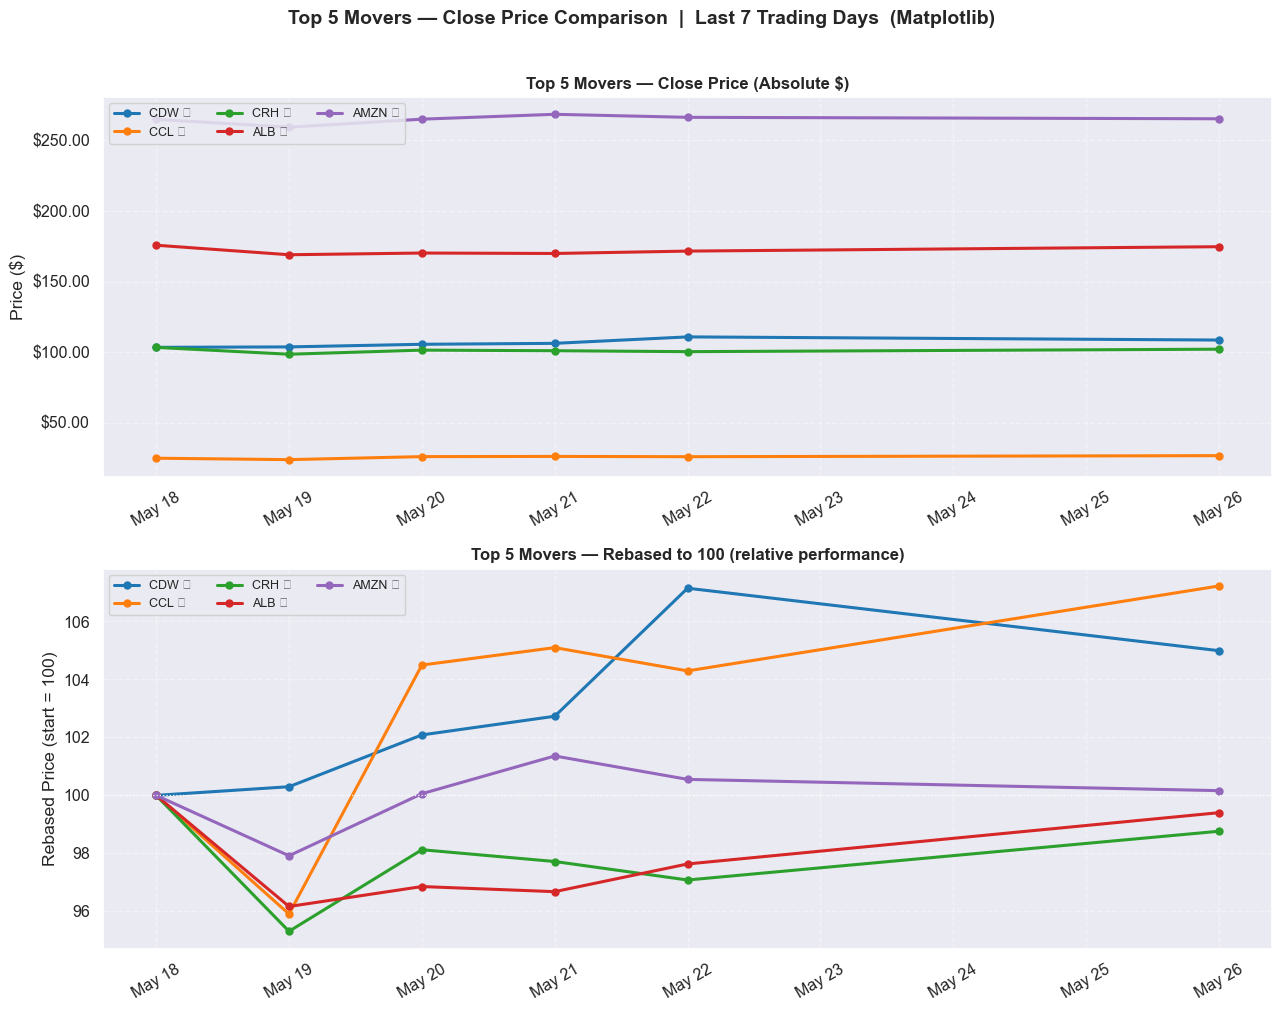

In [3]:
# =============================================================================
# CELL 3 — TOP 5 MOVERS VISUALIZATIONS
# 
# Visualizes the data from Cell 1 (ohlc_data, top5_symbols)
# Charts:
#   [1] Seaborn OHLC line charts (one per stock, faceted layout)
#   [2] Matplotlib close price comparison (absolute $ + rebased %)
# =============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import pandas as pd

# Guard
if not globals().get("ohlc_data"):
    raise RuntimeError("ohlc_data is missing — run Cell 1 first.")

OHLC_COLORS  = {"Open": "#4C72B0", "High": "#2ecc71", "Low": "#e74c3c", "Close": "#9b59b6"}
OHLC_MARKERS = {"Open": "o",       "High": "^",        "Low": "v",       "Close": "s"}

def dollar_fmt(v, _): return f"${v:,.2f}"


# CHART 1 — Seaborn: Top 5 Movers OHLC Line Charts (faceted, one per stock)
print("Rendering Chart 1 — Top 5 Movers OHLC …")

n = len(ohlc_data)
fig, axes = plt.subplots(n, 1, figsize=(13, 4.5 * n))
axes = [axes] if n == 1 else list(axes)

sns.set_theme(style="darkgrid", palette="tab10", font_scale=1.05)

for ax, (sym, df) in zip(axes, ohlc_data.items()):
    df_long = (
        df.reset_index()
          .rename(columns={"index": "Date"})
          .melt(id_vars="Date", var_name="Price Type", value_name="Price")
    )
    for pt in ["Open", "High", "Low", "Close"]:
        sub = df_long[df_long["Price Type"] == pt]
        sns.lineplot(
            data=sub, x="Date", y="Price", ax=ax,
            label=pt, color=OHLC_COLORS[pt],
            marker=OHLC_MARKERS[pt], linewidth=2, markersize=8,
        )

    ax.fill_between(df.index, df["Low"], df["High"],
                    alpha=0.08, color="#888888", label="_nolegend_")

    company = get_company_name(sym)
    ax.set_title(f"{sym} — {company}  |  {OHLC_DAYS}-Day OHLC",
                 fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Price ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Price Type", loc="upper left", framealpha=0.85, ncol=4)

fig.suptitle("Top 5 Daily Movers — OHLC Line Charts  (Seaborn)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# CHART 2 — Matplotlib: Top 5 Movers Close Price Comparison
print("Rendering Chart 2 — Top 5 Movers Close Price Comparison …")

fig, (ax_abs, ax_norm) = plt.subplots(2, 1, figsize=(13, 10))
cmap   = plt.get_cmap("tab10")
colors = {sym: cmap(i % 10) for i, sym in enumerate(ohlc_data)}

for sym, df in ohlc_data.items():
    label = f"{sym} ★"
    ax_abs.plot(df.index, df["Close"],
                color=colors[sym], linewidth=2.2,
                marker="o", markersize=5, label=label)
    rebased = df["Close"] / df["Close"].iloc[0] * 100
    ax_norm.plot(df.index, rebased,
                 color=colors[sym], linewidth=2.2,
                 marker="o", markersize=5, label=label)

ax_abs.set_title("Top 5 Movers — Close Price (Absolute $)",
                 fontsize=12, fontweight="bold")
ax_abs.set_ylabel("Price ($)")
ax_abs.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax_abs.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax_abs.tick_params(axis="x", rotation=30)
ax_abs.legend(fontsize=9, loc="upper left", framealpha=0.85, ncol=3)
ax_abs.grid(True, linestyle="--", alpha=0.4)

ax_norm.axhline(100, color="white", linewidth=0.9, linestyle=":")
ax_norm.set_title("Top 5 Movers — Rebased to 100 (relative performance)",
                  fontsize=12, fontweight="bold")
ax_norm.set_ylabel("Rebased Price (start = 100)")
ax_norm.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax_norm.tick_params(axis="x", rotation=30)
ax_norm.legend(fontsize=9, loc="upper left", framealpha=0.85, ncol=3)
ax_norm.grid(True, linestyle="--", alpha=0.4)

fig.suptitle(f"Top 5 Movers — Close Price Comparison  |  Last {OHLC_DAYS} Trading Days  (Matplotlib)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Watchlist Analysis & Charts

Monitor your favorite stocks (AAPL, NVDA, MSFT, META, GOOGL) with:
- Daily performance & 7-day price trends
- Candlestick-style OHLC visualization
- Absolute vs relative price comparison

**Data Source**: `watchlist_ohlc_data` & `watchlist_performance` from Cell 1
**Charts Generated**: 3 different visualizations for trend analysis

## Watchlist Charts - Candlestick & Trend Analysis

Detailed 7-day OHLC visualization for your watchlist stocks with:
- Candlestick-style price bars (green = bullish, red = bearish)
- Moving average trend lines
- Absolute and rebased price comparisons

**Ready to Execute**: Cell 4 generates all watchlist visualizations

Rendering Chart 1 — Watchlist % Change …


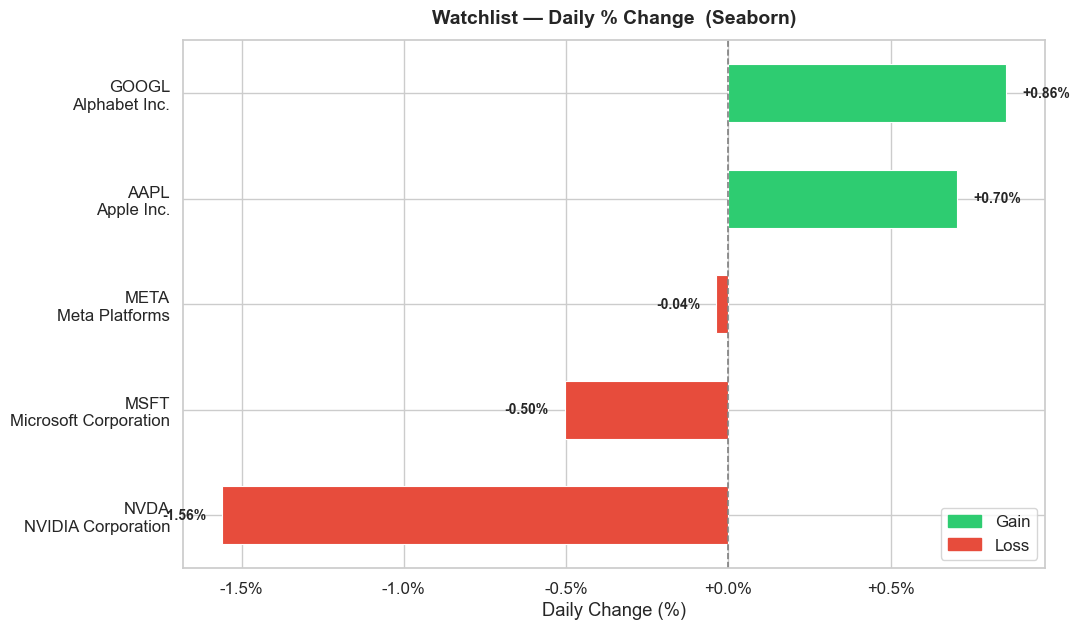

Rendering Chart 2 — Watchlist Candlestick OHLC …


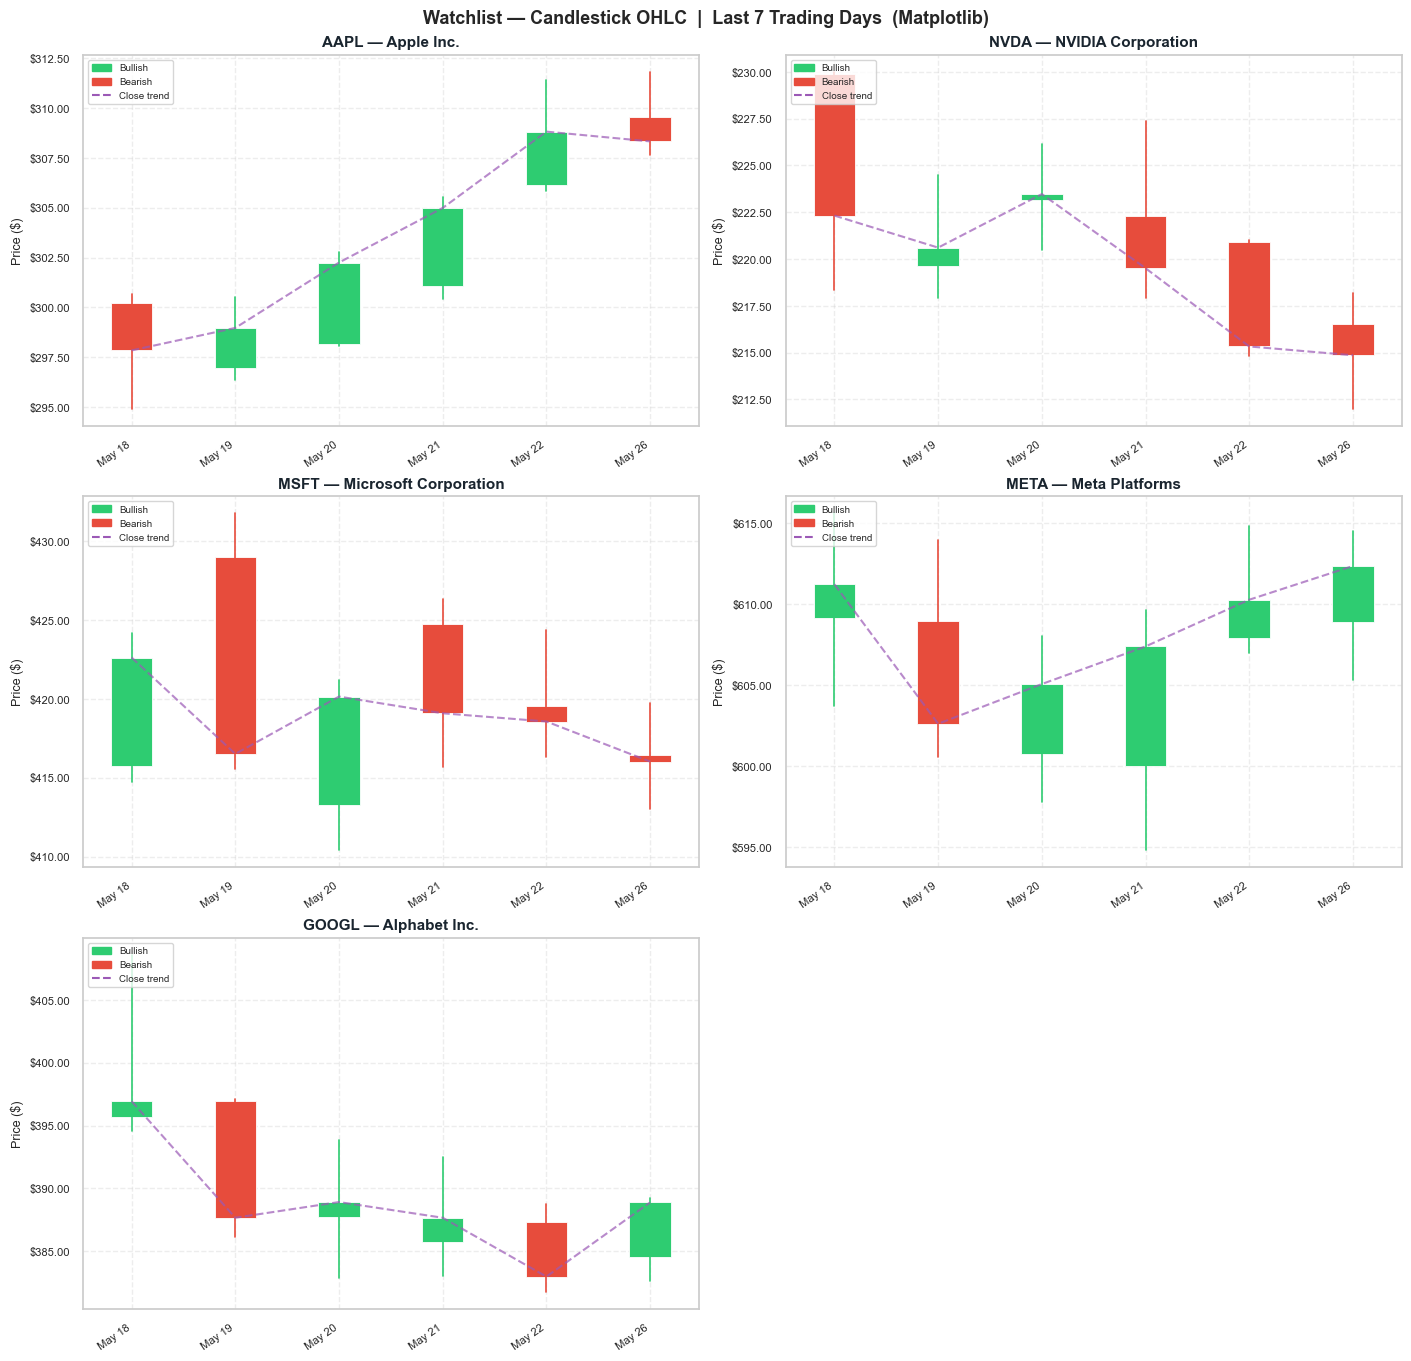

  ✓ Chart 2 complete.

Rendering Chart 3 — Watchlist Close Price Comparison …


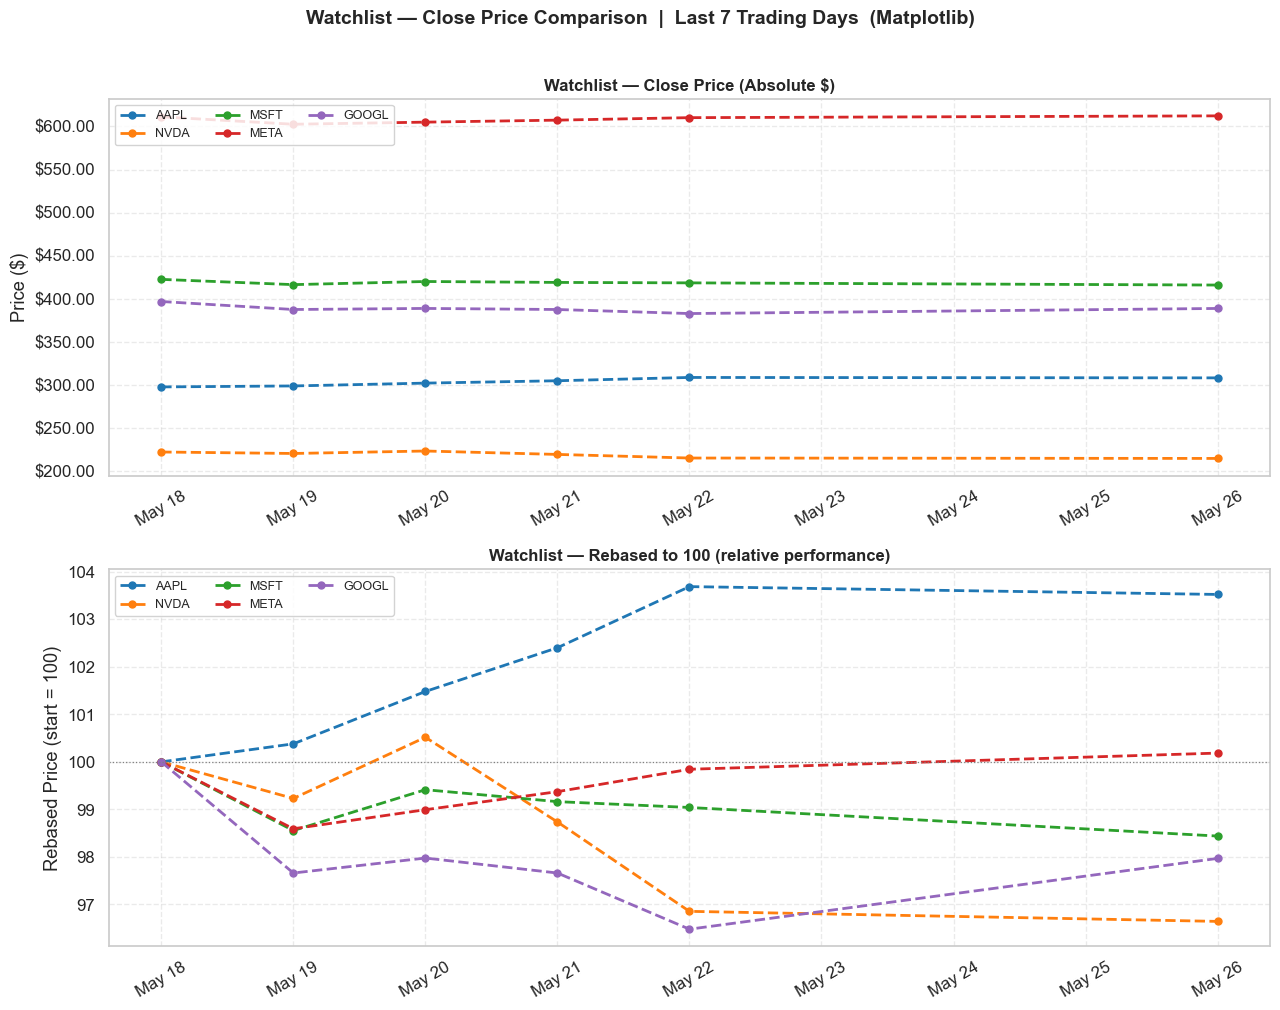

In [4]:
# =============================================================================
# CELL 4 — WATCHLIST VISUALIZATIONS
# 
# Visualizes watchlist data from Cell 1 (watchlist_ohlc_data, watchlist_performance)
# Charts:
#   [1] Seaborn bar chart — Daily % change for watchlist
#   [2] Matplotlib candlestick-style OHLC subplots
#   [3] Matplotlib close price comparison (absolute $ + rebased %)
# =============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# Guard
_missing = [n for n, v in [
    ("watchlist_ohlc_data",   globals().get("watchlist_ohlc_data")),
    ("watchlist_performance", globals().get("watchlist_performance")),
] if not v]
if _missing:
    raise RuntimeError(f"Missing from Cell 1: {_missing} — run Cell 1 first.")

def dollar_fmt(v, _): return f"${v:,.2f}"
def pct_fmt(v, _):    return f"{v:+.1f}%"

# CHART 1 — Seaborn: Watchlist Daily % Change Bar Chart
print("Rendering Chart 1 — Watchlist % Change …")

sns.set_theme(style="whitegrid", font_scale=1.1)

perf_df = pd.DataFrame(watchlist_performance, columns=["Symbol", "Pct"])
perf_df["Company"] = perf_df["Symbol"].map(get_company_name)
perf_df["Label"]   = perf_df["Symbol"] + "\n" + perf_df["Company"]
perf_df["Color"]   = perf_df["Pct"].apply(lambda v: "#2ecc71" if v >= 0 else "#e74c3c")
perf_df = perf_df.sort_values("Pct")

fig, ax = plt.subplots(figsize=(11, max(4, 0.9 * len(perf_df) + 2)))

bars = ax.barh(perf_df["Label"], perf_df["Pct"],
               color=perf_df["Color"].tolist(),
               edgecolor="white", linewidth=0.8, height=0.55)

for bar, val in zip(bars, perf_df["Pct"]):
    pad = 0.05
    ha  = "left" if val >= 0 else "right"
    ax.text(val + (pad if val >= 0 else -pad),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.2f}%", va="center", ha=ha,
            fontsize=10, fontweight="bold")

ax.axvline(0, color="gray", linewidth=1.2, linestyle="--")
ax.set_title("Watchlist — Daily % Change  (Seaborn)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Daily Change (%)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))

gain_patch = mpatches.Patch(color="#2ecc71", label="Gain")
loss_patch = mpatches.Patch(color="#e74c3c", label="Loss")
ax.legend(handles=[gain_patch, loss_patch], loc="lower right", framealpha=0.8)

plt.tight_layout()
plt.show()

# CHART 2 — Matplotlib: Watchlist Candlestick-style OHLC Subplots
print("Rendering Chart 2 — Watchlist Candlestick OHLC …")

n     = len(watchlist_ohlc_data)
ncols = 2
nrows = (n + 1) // ncols
fig, axs = plt.subplots(nrows, ncols,
                         figsize=(14, 4.5 * nrows),
                         constrained_layout=True)
axs_flat = list(axs.flatten()) if n > 1 else [axs]

for ax, (sym, df) in zip(axs_flat, watchlist_ohlc_data.items()):
    dates = np.arange(len(df))
    width = 0.4

    for i, (_, row) in enumerate(df.iterrows()):
        color  = "#2ecc71" if row["Close"] >= row["Open"] else "#e74c3c"
        bottom = min(row["Open"], row["Close"])
        height = abs(row["Close"] - row["Open"]) or 0.01
        ax.bar(i, height, bottom=bottom, width=width,
               color=color, edgecolor="white", linewidth=0.6)
        ax.plot([i, i], [row["Low"], row["High"]],
                color=color, linewidth=1.2)

    # Close trend overlay
    ax.plot(dates, df["Close"].values, color="#9b59b6",
            linewidth=1.5, linestyle="--", alpha=0.7, label="Close trend")

    company = get_company_name(sym)
    ax.set_title(f"{sym} — {company}", fontsize=11,
                 fontweight="bold", color="#1a252f")
    ax.set_ylabel("Price ($)", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
    ax.set_xticks(dates)
    ax.set_xticklabels(
        [d.strftime("%b %d") for d in df.index],
        rotation=35, ha="right", fontsize=8
    )
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(True, linestyle="--", alpha=0.35)

    up_p   = mpatches.Patch(color="#2ecc71", label="Bullish")
    down_p = mpatches.Patch(color="#e74c3c", label="Bearish")
    ax.legend(handles=[up_p, down_p,
                        plt.Line2D([0], [0], color="#9b59b6",
                                   linestyle="--", label="Close trend")],
              fontsize=7, loc="upper left", framealpha=0.8)

for ax in axs_flat[n:]:
    ax.set_visible(False)

fig.suptitle(
    f"Watchlist — Candlestick OHLC  |  Last {OHLC_DAYS} Trading Days  (Matplotlib)",
    fontsize=13, fontweight="bold"
)
plt.show()
print("  ✓ Chart 2 complete.\n")

# CHART 3 — Matplotlib: Watchlist Close Price Comparison (absolute + rebased)
print("Rendering Chart 3 — Watchlist Close Price Comparison …")

fig, (ax_abs, ax_norm) = plt.subplots(2, 1, figsize=(13, 10))
cmap   = plt.get_cmap("tab10")
colors = {sym: cmap(i % 10) for i, sym in enumerate(watchlist_ohlc_data)}

for sym, df in watchlist_ohlc_data.items():
    ax_abs.plot(df.index, df["Close"],
                color=colors[sym], linewidth=2,
                linestyle="--", marker="o", markersize=5, label=sym)
    rebased = df["Close"] / df["Close"].iloc[0] * 100
    ax_norm.plot(df.index, rebased,
                 color=colors[sym], linewidth=2,
                 linestyle="--", marker="o", markersize=5, label=sym)

ax_abs.set_title("Watchlist — Close Price (Absolute $)",
                 fontsize=12, fontweight="bold")
ax_abs.set_ylabel("Price ($)")
ax_abs.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax_abs.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax_abs.tick_params(axis="x", rotation=30)
ax_abs.legend(fontsize=9, loc="upper left", framealpha=0.85, ncol=3)
ax_abs.grid(True, linestyle="--", alpha=0.4)

ax_norm.axhline(100, color="gray", linewidth=0.9, linestyle=":")
ax_norm.set_title("Watchlist — Rebased to 100 (relative performance)",
                  fontsize=12, fontweight="bold")
ax_norm.set_ylabel("Rebased Price (start = 100)")
ax_norm.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax_norm.tick_params(axis="x", rotation=30)
ax_norm.legend(fontsize=9, loc="upper left", framealpha=0.85, ncol=3)
ax_norm.grid(True, linestyle="--", alpha=0.4)

fig.suptitle(f"Watchlist — Close Price Comparison  |  Last {OHLC_DAYS} Trading Days  (Matplotlib)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [5]:
# =============================================================================
# CELL 5 — FINAL INVESTMENT RECOMMENDATIONS
# Synthesizes all analysis into actionable recommendations
# =============================================================================

print("\n" + "=" * 80)
print(" 🎬 FINAL INVESTMENT RECOMMENDATIONS")
print("=" * 80)

print("\n" + "=" * 80)
print(" ⚠️  DISCLAIMER: This is educational analysis, not financial advice.")
print(" Always do your own research & consult a financial advisor.")
print("=" * 80)

# Find best performers from Cell 2 analysis
best_mover = score_df.iloc[0] if not score_df.empty else None
best_watchlist = wl_score_df.iloc[0] if not wl_score_df.empty else None

print("\n📈 TOP PICK FROM MOVERS:")
if best_mover is not None and best_mover["Recommendation"] == "🟢 BUY":
    print(f"  ✅ {best_mover['Symbol']} — STRONG BUY SIGNAL")
    print(f"     Momentum Score: {best_mover['Score']:.2f}")
    print(f"     Daily Change: {best_mover['Momentum']:+.2f}%")
    print(f"     Action: Buy if entering new position / Add if existing")
else:
    print(f"  ⚠️  No strong buy signals in top movers (trending but volatile)")

print("\n💼 WATCHLIST RECOMMENDATION:")
if best_watchlist is not None and "BUY" in best_watchlist["Recommendation"]:
    print(f"  ✅ {best_watchlist['Symbol']} — MAINTAIN/ADD POSITION")
    print(f"     Trend Score: {best_watchlist['Score']:.2f}")
    print(f"     Action: Strong holder, consider adding on dips")
else:
    print(f"  ⚠️  Monitor watchlist for better entry points")

print("\n🎯 PORTFOLIO STRATEGY:")
print("""
  1️⃣  MOVERS (High Growth, High Risk):
      • Buy only if score > 5 (strong momentum + stability)
      • Use 5-10% of portfolio for high-volatility trades
      • Set stop-loss at -5% to limit downside risk
      
  2️⃣  WATCHLIST (Established, Lower Risk):
      • Hold if score > 1 (positive trend)
      • Add on dips below 7-day moving average
      • These are core holdings for long-term growth
      
  3️⃣  CASH MANAGEMENT:
      • Avoid averaging down into falling stocks
      • Rebalance when any position > 20% of portfolio
      • Keep 10-20% cash for buying opportunities
""")



 🎬 FINAL INVESTMENT RECOMMENDATIONS

 ⚠️  DISCLAIMER: This is educational analysis, not financial advice.
 Always do your own research & consult a financial advisor.

📈 TOP PICK FROM MOVERS:
  ✅ AMZN — STRONG BUY SIGNAL
     Momentum Score: 19.41
     Daily Change: +2.31%
     Action: Buy if entering new position / Add if existing

💼 WATCHLIST RECOMMENDATION:
  ✅ AAPL — MAINTAIN/ADD POSITION
     Trend Score: 2.55
     Action: Strong holder, consider adding on dips

🎯 PORTFOLIO STRATEGY:

  1️⃣  MOVERS (High Growth, High Risk):
      • Buy only if score > 5 (strong momentum + stability)
      • Use 5-10% of portfolio for high-volatility trades
      • Set stop-loss at -5% to limit downside risk

  2️⃣  WATCHLIST (Established, Lower Risk):
      • Hold if score > 1 (positive trend)
      • Add on dips below 7-day moving average
      • These are core holdings for long-term growth

  3️⃣  CASH MANAGEMENT:
      • Avoid averaging down into falling stocks
      • Rebalance when any positi